# **Natural Language Processing**

In [1]:
import pandas as pd
import numpy as np
import re
import nltk

In [2]:
df = pd.read_csv("/content/amazonreviews.tsv", sep='\t')

In [3]:
df.shape

(10000, 2)

In [4]:
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [5]:
print(df.isnull().sum())

label     0
review    0
dtype: int64


In [6]:
df.dropna(inplace=True)

In [7]:
df.drop_duplicates(inplace=True)

**Download NLTK Resourcest**

In [8]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [9]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

**Text Preprocessing Function**

In [10]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [lemmatizer.lemmatize(word)
             for word in words
             if word not in stop_words]

    return " ".join(words)

**Apply Cleaning**

In [11]:
df['clean_review'] = df['review'].apply(clean_text)

df[['review', 'clean_review']].head()

,review,clean_review
0,Stuning even for the non-gamer: This sound tra...,stuning even non gamer sound track beautiful p...
1,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything reading lot revi...
2,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hand in...
3,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing played game kn...


**Sentiment Distribution**

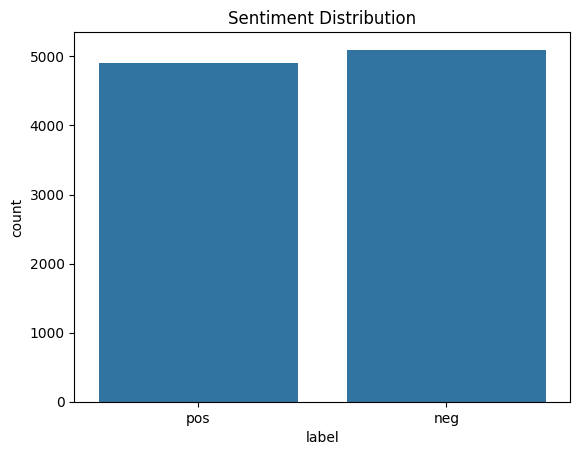

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=df)

plt.title("Sentiment Distribution")
plt.show()

**Positive Reviews Word Cloud**

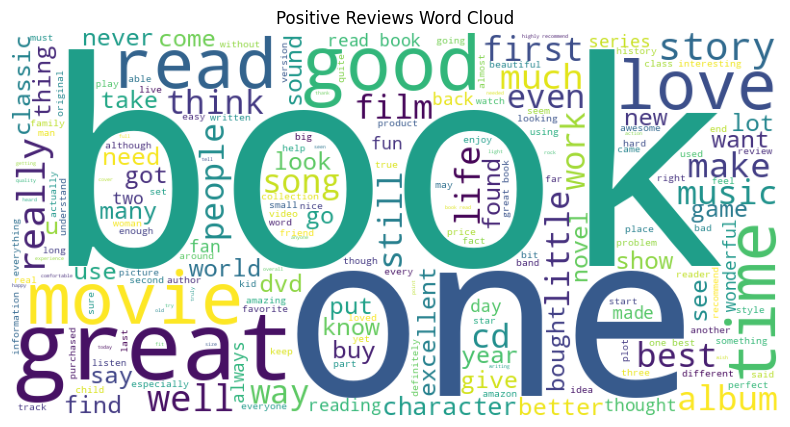

In [13]:
!pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_text = " ".join(df[df['label']=='pos']['clean_review'])
wordcloud = WordCloud( width=800,height=400,background_color='white').generate(positive_text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive Reviews Word Cloud")
plt.show()

**Negative Reviews Word Cloud**

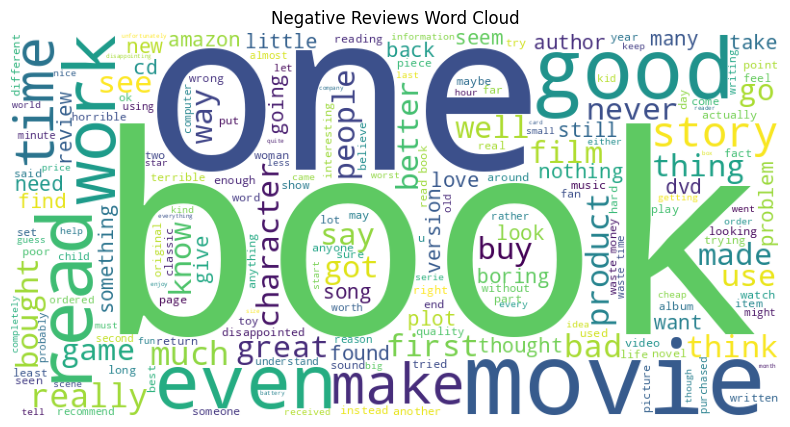

In [14]:
negative_text = " ".join(df[df['label']=='neg']['clean_review'])
wordcloud = WordCloud(width=800, height=400,background_color='white').generate(negative_text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Negative Reviews Word Cloud")
plt.show()

**Most Common Positive Words**

In [15]:
from collections import Counter

positive_words = " ".join(df[df['label']=='pos']['clean_review']).split()
top_positive = Counter(positive_words).most_common(10)
print(top_positive)

[('book', 3933), ('great', 2137), ('one', 1997), ('good', 1671), ('read', 1628), ('like', 1342), ('movie', 1330), ('time', 1189), ('love', 1045), ('would', 956)]


**Most Common Negative Words**

In [16]:
negative_words = " ".join(df[df['label']=='neg']['clean_review']).split()
op_negative = Counter(negative_words).most_common(10)
print(op_negative)

[('book', 3760), ('one', 2193), ('movie', 1784), ('like', 1592), ('would', 1465), ('time', 1321), ('get', 1299), ('read', 1275), ('good', 1163), ('even', 910)]


**Feature Extraction (TF-IDF)**

In [40]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

In [18]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_review'])
y = df['label']

**Train-Test Split**

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


**Model Training**

In [28]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [29]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

In [30]:
from sklearn.neural_network import MLPClassifier

nn_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=20,random_state=42)
nn_model.fit(X_train, y_train)
nn_pred = nn_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


In [48]:
def evaluate_model(model_name, y_test, y_pred):

    print("\n", model_name)

    print("Accuracy:",accuracy_score(y_test, y_pred))

    print("Precision:",precision_score(y_test, y_pred,pos_label='pos'))

    print("Recall:",recall_score(y_test, y_pred,pos_label='pos'))

    print("F1 Score:",f1_score(y_test, y_pred,pos_label='pos'))

    print(classification_report(y_test, y_pred))



In [46]:
print(y_train.unique())

['pos' 'neg']


In [47]:
evaluate_model("Logistic Regression",y_test, lr_pred)
evaluate_model("SVM",y_test, svm_pred)
evaluate_model("Neural Network",y_test, nn_pred)


 Logistic Regression
Accuracy: 0.8435
Precision: 0.8436213991769548
Recall: 0.835881753312946
F1 Score: 0.8397337429595494
              precision    recall  f1-score   support

         neg       0.84      0.85      0.85      1019
         pos       0.84      0.84      0.84       981

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000


 SVM
Accuracy: 0.8365
Precision: 0.8350409836065574
Recall: 0.8307849133537207
F1 Score: 0.8329075114971896
              precision    recall  f1-score   support

         neg       0.84      0.84      0.84      1019
         pos       0.84      0.83      0.83       981

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000


 Neural Network
Accuracy: 0.82
Precision: 0.8126888217522659
Recall: 0.8226299694189603
F1 Score: 0.817629179331

**Confusion Matrix**

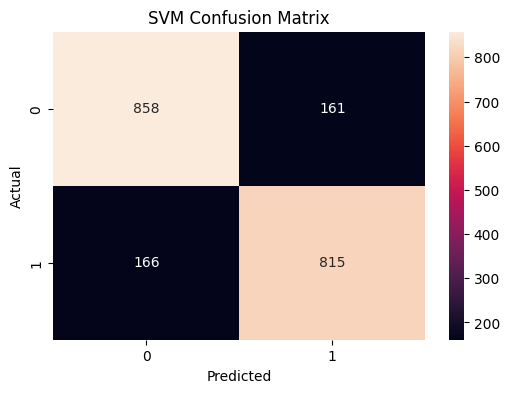

In [50]:
cm = confusion_matrix(y_test,svm_pred)
plt.figure(figsize=(6,4))

sns.heatmap(cm,annot=True,fmt='d')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [51]:
models = {

    "Logistic Regression":LogisticRegression(max_iter=1000),

    "SVM":LinearSVC(),

    "Neural Network":MLPClassifier( hidden_layer_sizes=(100,),max_iter=20,random_state=42)
}

**Cross Validation**

In [52]:
for name, model in models.items():

    scores = cross_val_score(model,X,y,cv=5,scoring='accuracy')

    print("\n", name)

    print("Cross Validation Accuracy:",scores.mean())



 Logistic Regression
Cross Validation Accuracy: 0.8388

 SVM
Cross Validation Accuracy: 0.827


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(



 Neural Network
Cross Validation Accuracy: 0.8073


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


In [53]:
results = pd.DataFrame({

    'Model':['Logistic Regression','SVM','Neural Network'],
    'Accuracy':[accuracy_score( y_test,lr_pred),accuracy_score( y_test,svm_pred),accuracy_score( y_test,nn_pred)],
    'Precision':[precision_score( y_test,lr_pred,pos_label='pos'),precision_score( y_test,svm_pred,pos_label='pos'),precision_score( y_test,nn_pred,pos_label='pos')],
    'Recall':[recall_score( y_test,lr_pred,pos_label='pos'),recall_score( y_test,svm_pred,pos_label='pos'),recall_score( y_test,nn_pred,pos_label='pos')],
    'F1 Score':[f1_score(y_test,lr_pred,pos_label='pos'),f1_score(y_test,svm_pred,pos_label='pos'),f1_score(y_test,nn_pred,pos_label='pos')]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression    0.8435   0.843621  0.835882  0.839734
1                  SVM    0.8365   0.835041  0.830785  0.832908
2       Neural Network    0.8200   0.812689  0.822630  0.817629


**Comparision plot**

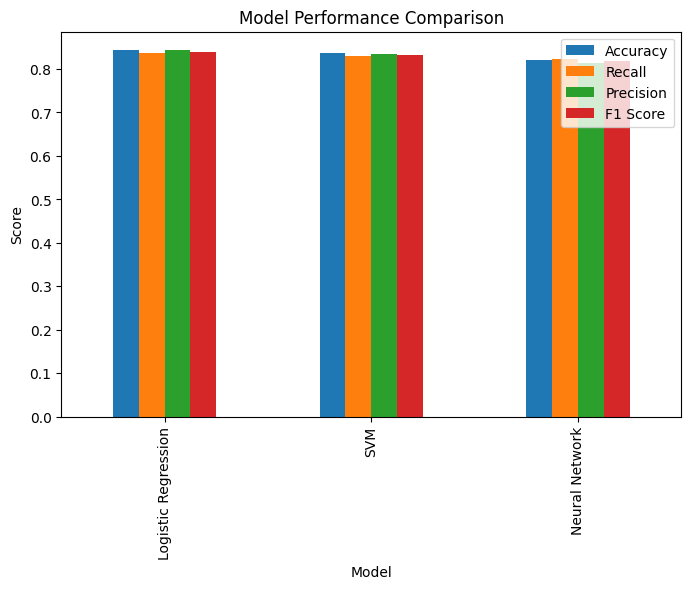

In [57]:
results.plot(x='Model',y=['Accuracy','Recall','Precision','F1 Score'],
    kind='bar',
    figsize=(8,5)
)

plt.title(
    "Model Performance Comparison"
)

plt.ylabel("Score")

plt.show()

In [62]:
def predict_sentiment(review):
    review = clean_text(review)
    review_vector = tfidf.transform([review])
    prediction = svm_model.predict(review_vector)[0]
    if prediction == 'pos':
        return "Positive Review"
    else:
        return "Negative Review"

In [61]:
print(
    predict_sentiment(
        "This product is amazing and works perfectly"
    )
)

print(
    predict_sentiment(
        "Worst product I have ever purchased"
    )
)

Positive Review
Negative Review
